In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries loaded!")

✓ All libraries loaded!


In [3]:
cars_df = pd.read_csv("C:\\Users\\Lenovo\\Downloads\\car data.csv")  

print("Dataset loaded successfully!")
print(f"Dataset Shape: {cars_df.shape}")
print("\nFirst 10 rows:")
print(cars_df.head(10))
print("\nColumn Names:")
print(cars_df.columns.tolist())
print("\nData Types:")
print(cars_df.dtypes)

Dataset loaded successfully!
Dataset Shape: (301, 9)

First 10 rows:
        Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0           ritz  2014           3.35           5.59       27000    Petrol   
1            sx4  2013           4.75           9.54       43000    Diesel   
2           ciaz  2017           7.25           9.85        6900    Petrol   
3        wagon r  2011           2.85           4.15        5200    Petrol   
4          swift  2014           4.60           6.87       42450    Diesel   
5  vitara brezza  2018           9.25           9.83        2071    Diesel   
6           ciaz  2015           6.75           8.12       18796    Petrol   
7        s cross  2015           6.50           8.61       33429    Diesel   
8           ciaz  2016           8.75           8.89       20273    Diesel   
9           ciaz  2015           7.45           8.92       42367    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0 

In [4]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)
print(cars_df.info())

print("\n" + "="*70)
print("STATISTICAL SUMMARY")
print("="*70)
print(cars_df.describe())

print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)
missing_values = cars_df.isnull().sum()
print(missing_values[missing_values > 0])

print("\n" + "="*70)
print("UNIQUE VALUES PER COLUMN")
print("="*70)
for col in cars_df.columns:
    unique_count = cars_df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    if unique_count <= 20 and unique_count > 0:
        print(f"  Sample values: {cars_df[col].unique()[:5]}")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

STATISTICAL SUMMARY
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915

In [5]:
price_column = None
price_keywords = ['price', 'cost', 'value', 'amount', 'selling']

for col in cars_df.columns:
    col_lower = col.lower()
    if any(keyword in col_lower for keyword in price_keywords):
        if cars_df[col].dtype in ['float64', 'int64']:
            price_column = col
            print(f"✓ Price column detected: {col}")
            break

if price_column is None:
    print("⚠ Could not detect price column. Showing all numeric columns:")
    print(cars_df.select_dtypes(include=[np.number]).columns.tolist())
    print("Please specify the price_column manually above.")
else:
    print(f"\nPrice Statistics:")
    print(cars_df[price_column].describe())
    
numerical_cols = cars_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = cars_df.select_dtypes(include=['object']).columns.tolist()

if price_column in numerical_cols:
    numerical_cols.remove(price_column)

print(f"\n✓ Numerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"✓ Categorical Features ({len(categorical_cols)}): {categorical_cols}")

✓ Price column detected: Selling_Price

Price Statistics:
count    301.000000
mean       4.661296
std        5.082812
min        0.100000
25%        0.900000
50%        3.600000
75%        6.000000
max       35.000000
Name: Selling_Price, dtype: float64

✓ Numerical Features (4): ['Year', 'Present_Price', 'Driven_kms', 'Owner']
✓ Categorical Features (4): ['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']


In [6]:
df_clean = cars_df.copy()

print("="*70)
print("DATA CLEANING")
print("="*70)

missing_before = df_clean.isnull().sum().sum()
print(f"\nTotal missing values before cleaning: {missing_before}")

if missing_before > 0:
    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"  Filled {col} with median: {median_val}")
    
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            mode_val = df_clean[col].mode()[0]
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"  Filled {col} with mode: {mode_val}")
    
    if df_clean[price_column].isnull().sum() > 0:
        rows_before = len(df_clean)
        df_clean = df_clean.dropna(subset=[price_column])
        print(f"  Dropped {rows_before - len(df_clean)} rows with missing prices")

print(f"\nTotal missing values after cleaning: {df_clean.isnull().sum().sum()}")

duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    print(f"\nRemoving {duplicates} duplicate rows...")
    df_clean = df_clean.drop_duplicates()

Q1 = df_clean[price_column].quantile(0.01)
Q3 = df_clean[price_column].quantile(0.99)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_before = len(df_clean)
df_clean = df_clean[(df_clean[price_column] >= lower_bound) & 
                    (df_clean[price_column] <= upper_bound)]
outliers_removed = outliers_before - len(df_clean)

if outliers_removed > 0:
    print(f"\nRemoved {outliers_removed} price outliers")
    print(f"Price range: ${df_clean[price_column].min():,.0f} - ${df_clean[price_column].max():,.0f}")

print(f"\n✓ Clean dataset shape: {df_clean.shape}")

DATA CLEANING

Total missing values before cleaning: 0

Total missing values after cleaning: 0

Removing 2 duplicate rows...

✓ Clean dataset shape: (299, 9)


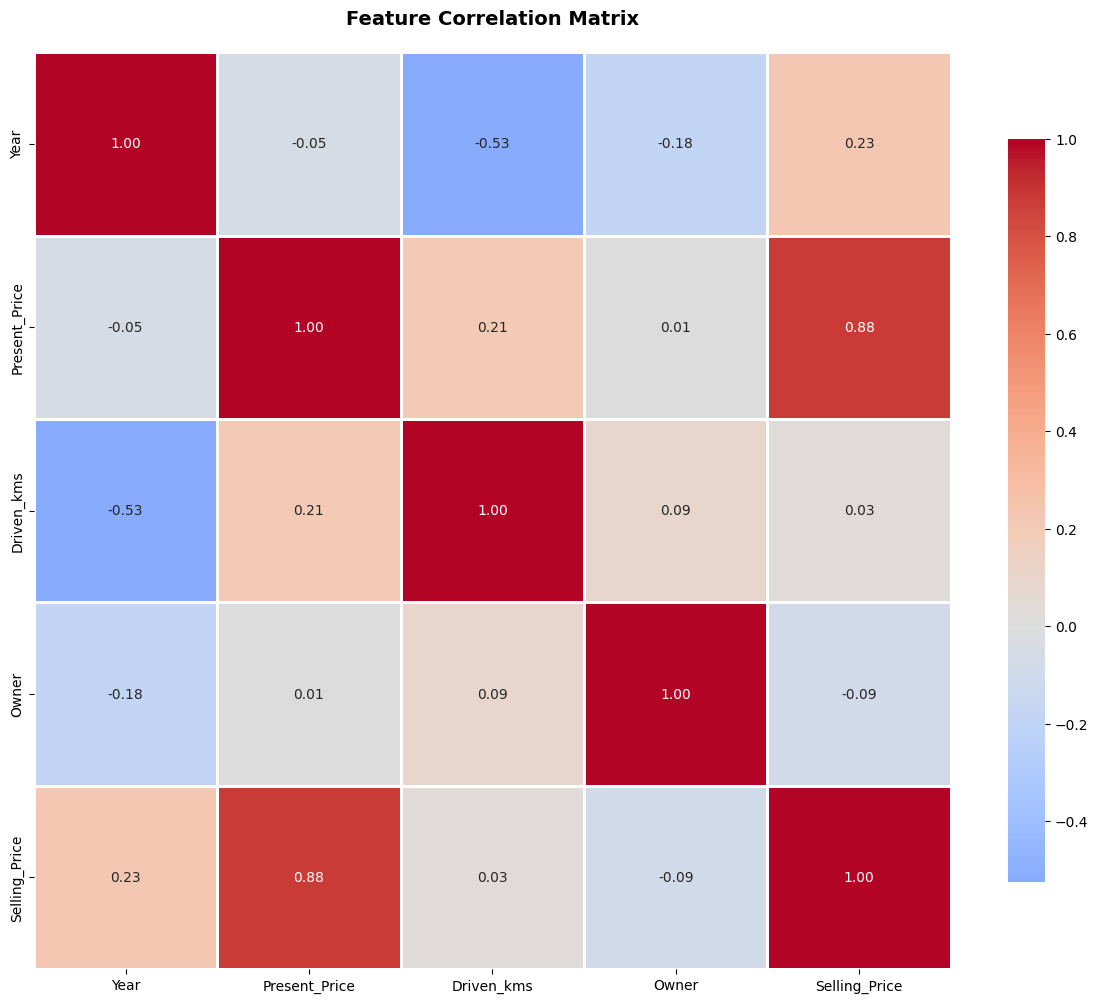


CORRELATION WITH PRICE
Present_Price: 0.8763
Year: 0.2344
Driven_kms: 0.0286
Owner: -0.0879


In [9]:
if len(numerical_cols) > 0:
    corr_cols = numerical_cols + [price_column]
    correlation_matrix = df_clean[corr_cols].corr()
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("CORRELATION WITH PRICE")
    print("="*70)
    price_corr = correlation_matrix[price_column].sort_values(ascending=False)
    for feature, corr in price_corr.items():
        if feature != price_column:
            print(f"{feature}: {corr:.4f}")

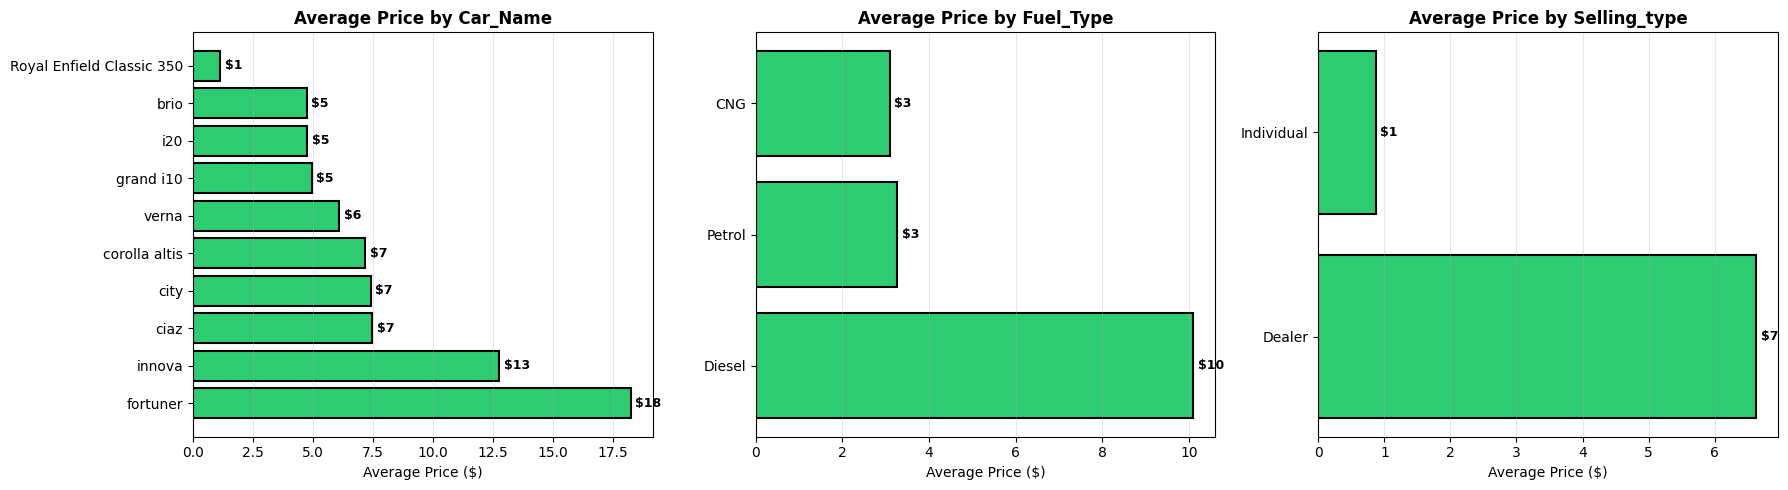

In [10]:
if len(categorical_cols) > 0:
    n_cat = min(3, len(categorical_cols))
    fig, axes = plt.subplots(1, n_cat, figsize=(6*n_cat, 5))
    
    if n_cat == 1:
        axes = [axes]
    
    for idx in range(n_cat):
        cat_col = categorical_cols[idx]
        
        top_cats = df_clean[cat_col].value_counts().head(10).index
        filtered = df_clean[df_clean[cat_col].isin(top_cats)]
        
        cat_avg = filtered.groupby(cat_col)[price_column].mean().sort_values(ascending=False)
        
        axes[idx].barh(cat_avg.index, cat_avg.values, 
                      color='#2ecc71', edgecolor='black', linewidth=1.5)
        axes[idx].set_title(f'Average Price by {cat_col}', 
                           fontsize=12, fontweight='bold')
        axes[idx].set_xlabel('Average Price ($)', fontsize=10)
        axes[idx].grid(alpha=0.3, axis='x')
        
        for i, v in enumerate(cat_avg.values):
            axes[idx].text(v + max(cat_avg.values)*0.01, i, f'${v:,.0f}', 
                          va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

In [11]:
df_model = df_clean.copy()

label_encoders = {}

print("="*70)
print("ENCODING CATEGORICAL VARIABLES")
print("="*70)

for col in categorical_cols:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le
        print(f"✓ Encoded {col}: {len(le.classes_)} unique categories")

print(f"\n✓ Total categorical variables encoded: {len(label_encoders)}")

ENCODING CATEGORICAL VARIABLES
✓ Encoded Car_Name: 98 unique categories
✓ Encoded Fuel_Type: 3 unique categories
✓ Encoded Selling_type: 2 unique categories
✓ Encoded Transmission: 2 unique categories

✓ Total categorical variables encoded: 4


In [12]:
X = df_model.drop(columns=[price_column])
y = df_model[price_column]

print("="*70)
print("FEATURE AND TARGET PREPARATION")
print("="*70)
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\nFeatures included: {X.columns.tolist()}")
print(f"\nTarget variable: {price_column}")
print(f"  Min: ${y.min():,.0f}")
print(f"  Max: ${y.max():,.0f}")
print(f"  Mean: ${y.mean():,.0f}")
print(f"  Median: ${y.median():,.0f}")

FEATURE AND TARGET PREPARATION
Feature matrix shape: (299, 8)
Target vector shape: (299,)

Features included: ['Car_Name', 'Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Target variable: Selling_Price
  Min: $0
  Max: $35
  Mean: $5
  Median: $4


In [13]:
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42
)

print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)
print(f"Training set: {X_train.shape[0]} samples ({(1-test_size)*100:.0f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({test_size*100:.0f}%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Features scaled successfully!")
print(f"Scaled training data mean: {X_train_scaled.mean():.6f}")
print(f"Scaled training data std: {X_train_scaled.std():.6f}")

TRAIN-TEST SPLIT
Training set: 239 samples (80%)
Testing set: 60 samples (20%)

✓ Features scaled successfully!
Scaled training data mean: -0.000000
Scaled training data std: 1.000000


In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10),
    'Lasso Regression': Lasso(alpha=10),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5)
}

model_results = {}

print("="*70)
print("TRAINING CAR PRICE PREDICTION MODELS")
print("="*70)

for model_name, model in models.items():
    print(f"\n{'─'*70}")
    print(f"Training: {model_name}")
    print(f"{'─'*70}")
    
    model.fit(X_train_scaled, y_train)
    
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    model_results[model_name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'rmse': test_rmse,
        'mae': test_mae,
        'predictions': y_pred_test
    }
    
    print(f"Training R²: {train_r2:.4f}")
    print(f"Testing R²: {test_r2:.4f}")
    print(f"RMSE: ${test_rmse:,.2f}")
    print(f"MAE: ${test_mae:,.2f}")
    
    mape = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100
    print(f"MAPE: {mape:.2f}%")

TRAINING CAR PRICE PREDICTION MODELS

──────────────────────────────────────────────────────────────────────
Training: Linear Regression
──────────────────────────────────────────────────────────────────────
Training R²: 0.9029
Testing R²: 0.7350
RMSE: $2.61
MAE: $1.57
MAPE: 151.81%

──────────────────────────────────────────────────────────────────────
Training: Ridge Regression
──────────────────────────────────────────────────────────────────────
Training R²: 0.9015
Testing R²: 0.7352
RMSE: $2.61
MAE: $1.56
MAPE: 142.44%

──────────────────────────────────────────────────────────────────────
Training: Lasso Regression
──────────────────────────────────────────────────────────────────────
Training R²: 0.0000
Testing R²: -0.0000
RMSE: $5.08
MAE: $3.33
MAPE: 404.04%

──────────────────────────────────────────────────────────────────────
Training: Decision Tree
──────────────────────────────────────────────────────────────────────
Training R²: 0.9997
Testing R²: 0.6051
RMSE: $3.19
MAE: 

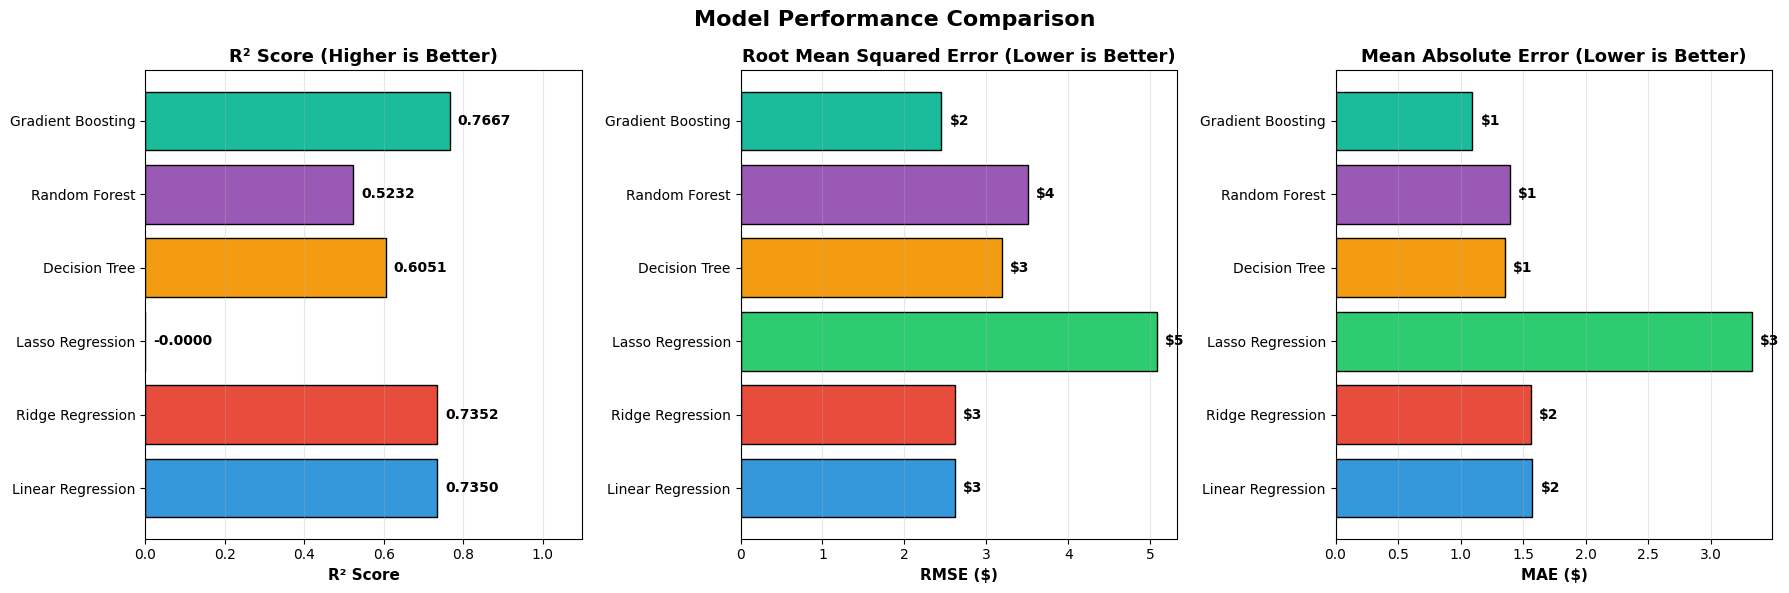

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

model_names = list(model_results.keys())

test_r2_scores = [model_results[name]['test_r2'] for name in model_names]
colors_r2 = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

bars = axes[0].barh(model_names, test_r2_scores, color=colors_r2[:len(model_names)], 
                    edgecolor='black')
for i, (bar, score) in enumerate(zip(bars, test_r2_scores)):
    axes[0].text(score + 0.02, i, f'{score:.4f}', 
                va='center', fontweight='bold', fontsize=10)

axes[0].set_xlabel('R² Score', fontsize=11, fontweight='bold')
axes[0].set_title('R² Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[0].set_xlim(0, 1.1)
axes[0].grid(alpha=0.3, axis='x')

rmse_scores = [model_results[name]['rmse'] for name in model_names]

bars = axes[1].barh(model_names, rmse_scores, color=colors_r2[:len(model_names)], 
                    edgecolor='black')
for i, (bar, score) in enumerate(zip(bars, rmse_scores)):
    axes[1].text(score + max(rmse_scores)*0.02, i, f'${score:,.0f}', 
                va='center', fontweight='bold', fontsize=10)

axes[1].set_xlabel('RMSE ($)', fontsize=11, fontweight='bold')
axes[1].set_title('Root Mean Squared Error (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

mae_scores = [model_results[name]['mae'] for name in model_names]

bars = axes[2].barh(model_names, mae_scores, color=colors_r2[:len(model_names)], 
                    edgecolor='black')
for i, (bar, score) in enumerate(zip(bars, mae_scores)):
    axes[2].text(score + max(mae_scores)*0.02, i, f'${score:,.0f}', 
                va='center', fontweight='bold', fontsize=10)

axes[2].set_xlabel('MAE ($)', fontsize=11, fontweight='bold')
axes[2].set_title('Mean Absolute Error (Lower is Better)', fontsize=13, fontweight='bold')
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [19]:
print("\n" + "="*70)
print("PRICE PREDICTION FOR NEW CARS")
print("="*70)

print("\nTo predict prices for new cars, prepare data in this format:")
print(f"Required columns: {X.columns.tolist()}")

sample_indices = np.random.choice(len(X_test), size=min(5, len(X_test)), replace=False)
sample_cars = X_test.iloc[sample_indices].copy()
sample_actuals = y_test.iloc[sample_indices]

sample_scaled = scaler.transform(sample_cars)
sample_predictions = best_model_info['model'].predict(sample_scaled)

print("\n" + "─"*70)
print("SAMPLE PREDICTIONS (from test set)")
print("─"*70)

for i in range(len(sample_indices)):
    print(f"\nCar {i+1}:")
    for col in X.columns[:min(5, len(X.columns))]:
        if col in label_encoders:
            decoded_value = label_encoders[col].inverse_transform([int(sample_cars.iloc[i][col])])[0]
            print(f"  {col}: {decoded_value}")
        else:
            print(f"  {col}: {sample_cars.iloc[i][col]}")
    
    print(f"  Actual Price: ${sample_actuals.iloc[i]:,.2f}")
    print(f"  Predicted Price: ${sample_predictions[i]:,.2f}")
    print(f"  Difference: ${abs(sample_actuals.iloc[i] - sample_predictions[i]):,.2f}")
    print(f"  Error: {abs(sample_actuals.iloc[i] - sample_predictions[i])/sample_actuals.iloc[i]*100:.2f}%")


PRICE PREDICTION FOR NEW CARS

To predict prices for new cars, prepare data in this format:
Required columns: ['Car_Name', 'Year', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

──────────────────────────────────────────────────────────────────────
SAMPLE PREDICTIONS (from test set)
──────────────────────────────────────────────────────────────────────

Car 1:
  Car_Name: camry
  Year: 2006.0
  Present_Price: 23.73
  Driven_kms: 142000.0
  Fuel_Type: Petrol
  Actual Price: $2.50
  Predicted Price: $12.70
  Difference: $10.20
  Error: 407.91%

Car 2:
  Car_Name: Yamaha FZ S V 2.0
  Year: 2015.0
  Present_Price: 0.84
  Driven_kms: 23000.0
  Fuel_Type: Petrol
  Actual Price: $0.48
  Predicted Price: $0.54
  Difference: $0.06
  Error: 12.02%

Car 3:
  Car_Name: Royal Enfield Thunder 350
  Year: 2016.0
  Present_Price: 1.5
  Driven_kms: 8700.0
  Fuel_Type: Petrol
  Actual Price: $1.15
  Predicted Price: $1.24
  Difference: $0.09
  Error: 7.76%

Car 4:

In [20]:
import pickle
import json

model_filename = f'best_car_price_model_{best_model_name.replace(" ", "_").lower()}.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model_info['model'], file)

scaler_filename = 'car_price_scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

encoders_filename = 'car_label_encoders.pkl'
with open(encoders_filename, 'wb') as file:
    pickle.dump(label_encoders, file)

print(f"\n✓ Model saved as: {model_filename}")
print(f"✓ Scaler saved as: {scaler_filename}")
print(f"✓ Encoders saved as: {encoders_filename}")

metadata = {
    'feature_columns': X.columns.tolist(),
    'model_name': best_model_name,
    'test_r2': float(best_model_info['test_r2']),
    'test_rmse': float(best_model_info['rmse']),
    'test_mae': float(best_model_info['mae'])
}

with open('car_model_metadata.json', 'w') as file:
    json.dump(metadata, file, indent=4)

print(f"✓ Metadata saved as: car_model_metadata.json")


✓ Model saved as: best_car_price_model_gradient_boosting.pkl
✓ Scaler saved as: car_price_scaler.pkl
✓ Encoders saved as: car_label_encoders.pkl
✓ Metadata saved as: car_model_metadata.json
